# Session 1: Python and NumPy

---
# Part 1: Python review

## 1.1 Data types


In [ ]:
# n_samples = 
# temperature = 
# gene_name = 
# is_tumor = 
# missing_value = 

## 1.2 Naming variables

PEP 8 says:

| What | Style | Example |
| --- | --- | --- |
| Variables and functions | `snake_case` | `n_samples`, `compute_gc_content` |
| Classes | `PascalCase` | `DNASequence`, `LinearRegression` |
| Constants | `UPPER_CASE` | `MAX_ITERATIONS` |

- **Be descriptive.** (`expression_matrix` not `m`.)
- **Never reuse a built-in name** (`list`, `sum`, `min`, `max`, `type` or `input`)

Exception in ML: the feature matrix is a capital `X` and the target is a lowercase `y`

Rewrite this code with good names. It computes the fraction of samples that are tumors.

```python
l = [0, 1, 1, 0, 1]
n = 0
for i in l:
    n = n + i
x = n / len(l)
```

## 1.3 Collections: list, tuple, dict, set

| Type | Looks like | Ordered | Changeable | Typical use |
| --- | --- | --- | --- | --- |
| `list` | `[1, 2, 3]` | yes | yes | a sequence of values |
| `tuple` | `(1, 2, 3)` | yes | no | a fixed group, like `(rows, cols)` |
| `dict` | `{"A": 1}` | by insertion | yes | look up a value by a key |
| `set` | `{1, 2, 3}` | no | yes | unique items, membership tests |

In [5]:
# indexing
genes = ["TP53", "BRCA1", "MYC", "GAPDH", "EGFR"]


In [13]:
# tuples
shape = (28, 28)

In [12]:
# dictionaries
codon_table = {"ATG": "Met", "TGG": "Trp", "TAA": "Stop"} # GGC is Gly

In [ ]:
# sets
oncogenes = {"MYC", "EGFR", "KRAS"}


True
{'MYC', 'EGFR'}


**Mutability trap.** Assigning a list to a new name does not copy it. Both names point to the *same* list.

In [15]:
a = [1, 2, 3]


## 1.4 Control flow

In [23]:
# if, elif, and else
expression = 7.3


In [21]:
# for with range: range(start, stop, step)

In [22]:
# enumerate: index and value together


In [24]:
# zip: walk through two lists side by side
lengths = [393, 1863, 439, 335, 1210]   # protein lengths (amino acids)


In [ ]:
# while: repeat until a condition becomes False
population = 1
generations = 0

## 1.5 List comprehensions

A compact way to build a list from a loop, optionally with a condition:

```python
[expression for item in iterable if condition]
```

In [25]:
# squares


In [26]:
# even_squares 


In [27]:
# Two loops: the left `for` is the outer loop

### ✏️ Exercise 1

1. Use a list comprehension to create a list `mynumbers` of all numbers of the form $x^y$, with $x = 1, \dots, 10$, $y = 2, \dots, 7$ and $y > x$.
2. Compute the sum of the square roots of these numbers and store it in `total`. (`np.sqrt` and `np.sum` work on lists.)

## 1.6 Functions

`def` creates a function. Arguments can have **default values**. Variables created inside a function are **local**: they disappear when the function returns.

In [30]:
seq = "ATGCGC"

### ✏️ Exercise 2

1. Write a function `my_minimum(v)` that returns the smallest entry of a vector **without** using built-ins such as `min` or `np.minimum`. Use a loop. (And don't call any variable `min`!)
2. Test it on a vector of 10 random integers between 1 and 100. Note that `rng.integers(1, 101, size=10)` excludes the upper bound, so this gives 1 to 100.

## 1.7 `*args` and `**kwargs`

- `*args` collects any number of **positional** arguments into a tuple.
- `**kwargs` collects any number of **keyword** arguments into a dict.

Examples:
- `plt.plot(x, y, color="r", linewidth=2)`
- `model.set_params(**params)`

In [17]:
def describe(*args, **kwargs):
    print("args   =", args)
    print("kwargs =", kwargs)

describe(1, 2, 3, color="red", size=10)

args   = (1, 2, 3)
kwargs = {'color': 'red', 'size': 10}


In [2]:
# Unpacking goes the other way: * spreads a list, ** spreads a dict
def make_label(gene, organism, unit="TPM"):
    return f"{gene} ({organism}), {unit}"

settings = {"organism": "human", "unit": "FPKM"}


### ✏️ Write `mean_of(*numbers)` that returns the mean of any number of arguments, e.g. `mean_of(1, 2, 3)` gives `2.0`.

## 1.8 `lambda`

A `lambda` is a tiny one-line function without a name. It is handy when a function wants another function as an argument, like `sorted(key=...)` here, or pandas `apply` next session.

In [31]:
# Sort genes by protein length, using zip to keep the pairs together


## 1.9 Imports and f-strings

In [40]:
# numpy, mean and math

## 1.10 Errors: reading tracebacks and `try/except`

When something breaks, Python prints a **traceback**. Read it **from the bottom up**: the last line says *what* went wrong, and the lines above it say *where*.

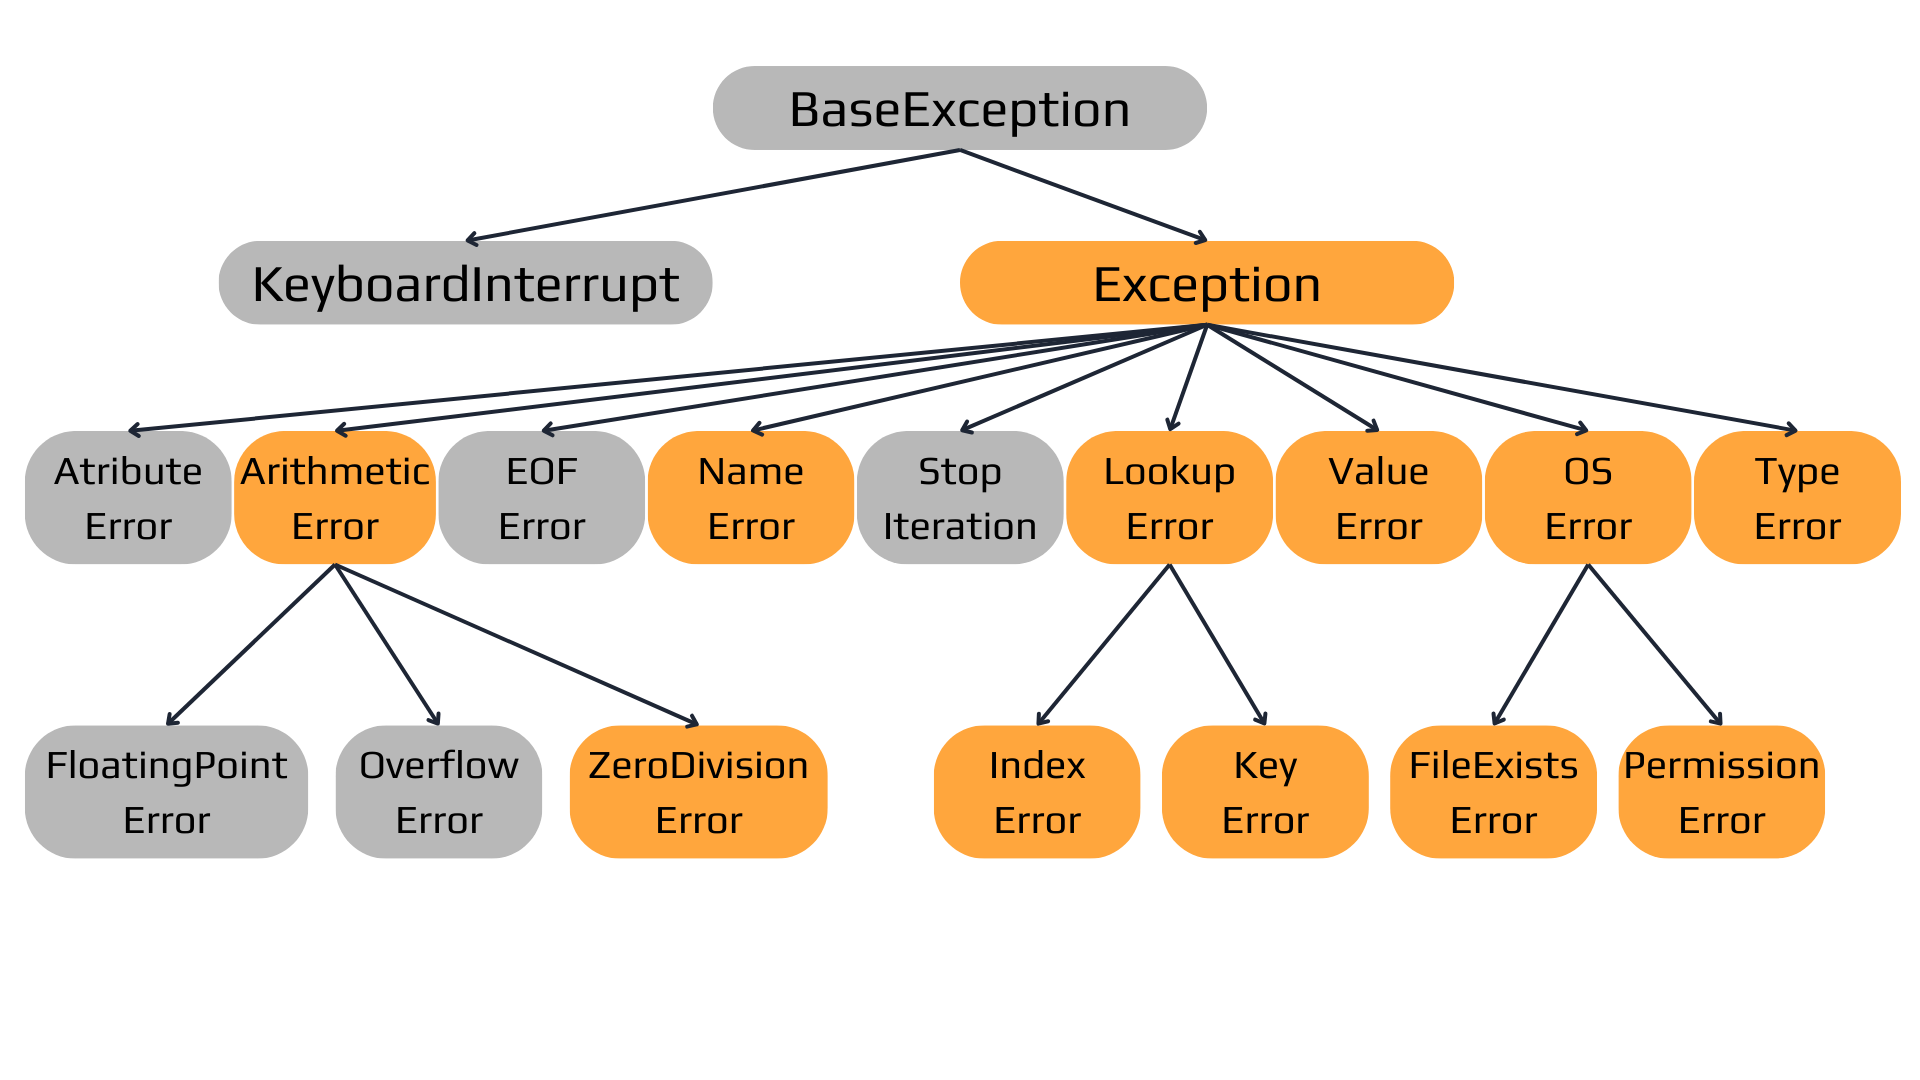

In [35]:
# average_expression

`try/except` lets you handle an error you **expect**. Catch the specific error type, never a bare `except:`. A bare `except` also hides the bugs you don't expect.

In [38]:
raw_values = ["3.2", "4.8", "NA", "5.1"]   # "NA" is common in real data files
parsed = []

### ✏️ Your turn

Write `safe_ratio(a, b)` that returns `a / b`, or `None` if `b` is zero. Use `try/except` with the right error type.

In [39]:
# def safe_ratio(a, b):


## 1.11 Getting help yourself

Before asking anyone, try:

- `np.linspace?` in a notebook cell shows the docstring. `help(np.linspace)` does the same anywhere.
- Hover over a function, or press `ctrl + space` after `np.`, to see what exists.
- Search the official docs (numpy.org, scikit-learn.org) and read a page in this order: **signature → parameters → returns → examples**. The examples at the bottom are often the fastest way in.

In [4]:
np.linspace?

Signature:      
np.linspace(
    start,
    stop,
    num=50,
    endpoint=True,
    retstep=False,
    dtype=None,
    axis=0,
    *,
    device=None,
)
Call signature:  np.linspace(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function linspace at 0x000002998B4AB880>
File:            c:\users\hossein\appdata\roaming\python\python310\site-packages\numpy\_core\function_base.py
Docstring:      
Return evenly spaced numbers over a specified interval.

Returns `num` evenly spaced samples, calculated over the
interval [`start`, `stop`].

The endpoint of the interval can optionally be excluded.

.. versionchanged:: 1.20.0
    Values are rounded towards ``-inf`` instead of ``0`` when an
    integer ``dtype`` is specified. The old behavior can
    still be obtained with ``np.linspace(start, stop, num).astype(int)``

Parameters
----------
start : array_like
    The starting value of the sequence.
stop : array_like
    The end value of the sequence, unless `endpo